In [1]:
import os
from pathlib import Path
import pandas as pd
import gc
import numpy as np

BASE_PATH = Path.cwd().parents[0]
SILVER_PATH = BASE_PATH / "data" / "silver"
GOLD_PATH = BASE_PATH / "data" / "gold"

SILVER_PATH.mkdir(parents=True, exist_ok=True)
GOLD_PATH.mkdir(parents=True, exist_ok=True)

In [2]:
df=pd.read_csv(SILVER_PATH / "la_integrated_dataset_2024.csv")

In [3]:
# df is your integrated dataset (Silver layer)
# Example:
# df = pd.read_csv("la_integrated_dataset.csv")

print("Initial shape:", df.shape)
print("Initial columns:\n", df.columns.tolist())
df = df.copy()


Initial shape: (233520, 36)
Initial columns:
 ['PortCallID', 'MMSI', 'IMO', 'VesselName', 'PortCode', 'ArrivalTime', 'BerthStartTime', 'DepartureTime', 'AnchorageWaitingTime', 'BerthTime', 'HandledTEU', 'PortCallStatus', 'AvgSOG', 'MaxSOG', 'AvgCOG', 'AISPoints', 'WaitingPoints', 'VesselDraft', 'VesselLength', 'VesselWidth', 'Date', 'TerminalID', 'BerthID', 'BerthLength', 'BerthDepth', 'MaxLOA', 'BerthMaxDraft', 'DailyCapacityTEU', 'OperationalStatus', 'SlotStart', 'SlotEnd', 'ArrivalHour', 'ArrivalDayOfWeek', 'IsWeekend', 'CongestionLevel', 'BerthFeasible']


In [4]:
df.dtypes

PortCallID               object
MMSI                      int64
IMO                      object
VesselName               object
PortCode                 object
ArrivalTime              object
BerthStartTime           object
DepartureTime            object
AnchorageWaitingTime    float64
BerthTime               float64
HandledTEU                int64
PortCallStatus           object
AvgSOG                  float64
MaxSOG                  float64
AvgCOG                  float64
AISPoints                 int64
WaitingPoints             int64
VesselDraft             float64
VesselLength            float64
VesselWidth             float64
Date                     object
TerminalID               object
BerthID                  object
BerthLength               int64
BerthDepth              float64
MaxLOA                    int64
BerthMaxDraft           float64
DailyCapacityTEU          int64
OperationalStatus        object
SlotStart                object
SlotEnd                  object
ArrivalH

In [5]:
num_df = df.select_dtypes(include=[np.number])

print(num_df.columns)

Index(['MMSI', 'AnchorageWaitingTime', 'BerthTime', 'HandledTEU', 'AvgSOG',
       'MaxSOG', 'AvgCOG', 'AISPoints', 'WaitingPoints', 'VesselDraft',
       'VesselLength', 'VesselWidth', 'BerthLength', 'BerthDepth', 'MaxLOA',
       'BerthMaxDraft', 'DailyCapacityTEU', 'ArrivalHour', 'ArrivalDayOfWeek',
       'IsWeekend', 'BerthFeasible'],
      dtype='object')


In [6]:
# Check NaN count
num_df.isna().sum()


MMSI                       0
AnchorageWaitingTime       0
BerthTime                  0
HandledTEU                 0
AvgSOG                     0
MaxSOG                     0
AvgCOG                     0
AISPoints                  0
WaitingPoints              0
VesselDraft                0
VesselLength               0
VesselWidth             3780
BerthLength                0
BerthDepth                 0
MaxLOA                     0
BerthMaxDraft              0
DailyCapacityTEU           0
ArrivalHour                0
ArrivalDayOfWeek           0
IsWeekend                  0
BerthFeasible              0
dtype: int64

In [7]:
# Check infinite values
np.isinf(num_df).sum()


MMSI                    0
AnchorageWaitingTime    0
BerthTime               0
HandledTEU              0
AvgSOG                  0
MaxSOG                  0
AvgCOG                  0
AISPoints               0
WaitingPoints           0
VesselDraft             0
VesselLength            0
VesselWidth             0
BerthLength             0
BerthDepth              0
MaxLOA                  0
BerthMaxDraft           0
DailyCapacityTEU        0
ArrivalHour             0
ArrivalDayOfWeek        0
IsWeekend               0
BerthFeasible           0
dtype: int64

In [8]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select numeric columns
num_df = df.select_dtypes(include=[np.number])

# 2. Replace inf with NaN
num_df = num_df.replace([np.inf, -np.inf], np.nan)

# 3. Drop rows with NaN (OK for VIF analysis)
num_df = num_df.dropna()

# 4. Drop constant columns
num_df = num_df.loc[:, num_df.nunique() > 1]

# 5. Compute VIF
vif_df = pd.DataFrame({
    "Feature": num_df.columns,
    "VIF": [variance_inflation_factor(num_df.values, i)
            for i in range(num_df.shape[1])]
}).sort_values(by="VIF", ascending=False)

print(vif_df)


C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                 Feature        VIF
14                MaxLOA        inf
13            BerthDepth        inf
12           BerthLength        inf
7              AISPoints        inf
8          WaitingPoints        inf
15         BerthMaxDraft        inf
10          VesselLength  11.678664
11           VesselWidth   7.517349
3             HandledTEU   3.418351
9            VesselDraft   2.992609
18      ArrivalDayOfWeek   2.741015
19             IsWeekend   2.721465
20         BerthFeasible   1.855736
2              BerthTime   1.852096
1   AnchorageWaitingTime   1.748424
5                 MaxSOG   1.458981
4                 AvgSOG   1.381950
17           ArrivalHour   1.050941
0                   MMSI   1.027565
6                 AvgCOG   1.023402
16      DailyCapacityTEU   1.000826


In [9]:
corr_matrix = num_df.corr(method='pearson')

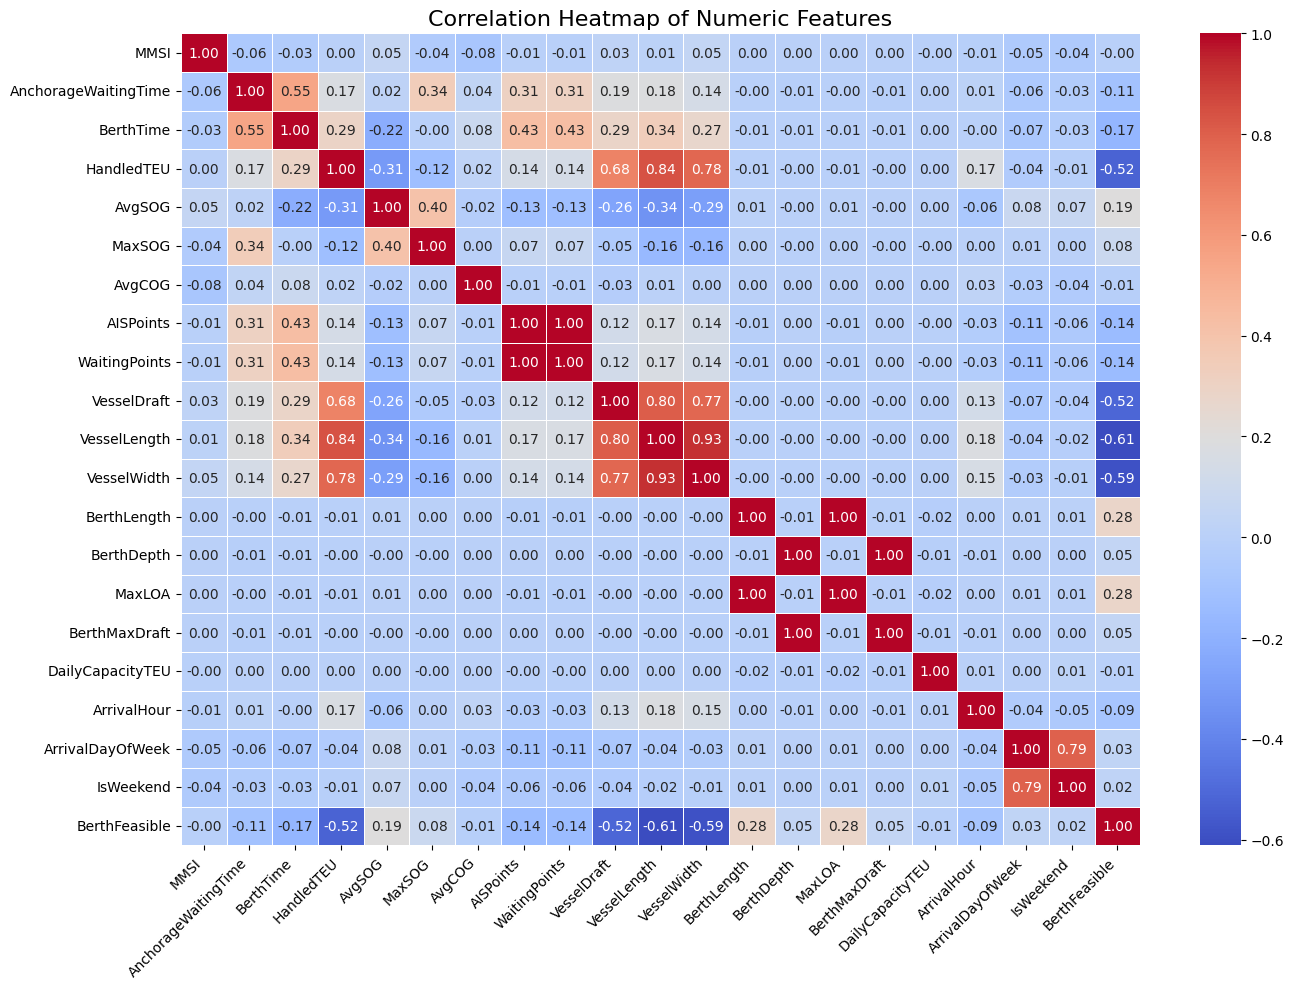

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
threshold = 0.8

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature_1", "Feature_2", "Correlation"]
)

print(high_corr_df.sort_values(by="Correlation", ascending=False))

       Feature_1     Feature_2  Correlation
0  WaitingPoints     AISPoints     1.000000
4         MaxLOA   BerthLength     1.000000
5  BerthMaxDraft    BerthDepth     1.000000
3    VesselWidth  VesselLength     0.926852
1   VesselLength    HandledTEU     0.839738
2   VesselLength   VesselDraft     0.804993


In [12]:
df["DelayMinutes"] = df["AnchorageWaitingTime"]

In [13]:
df["IsDelayed"] = (df["AnchorageWaitingTime"] > 360).astype(int)

In [14]:
df["DraftMargin"] = df["BerthDepth"] - df["VesselDraft"]


In [15]:
df["LOAMargin"] = df["MaxLOA"] - df["VesselLength"]


In [16]:
LEAKAGE_COLS = [
    "AnchorageWaitingTime",
    "PortCallStatus"
]

df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], inplace=True)


FINAL_KEEP_COLS = [
    # Operational outcome
    "BerthTime",

    # Vessel behavior
    "AvgSOG",
    "WaitingRatio",
    "VesselLength",
    "VesselDraft",

    # Time
    "ArrivalHour",
    "ArrivalDayOfWeek",

    # Port & berth constraints
    "TerminalID",
    "BerthID",
    "BerthDepth",
    "MaxLOA",
    "DailyCapacityTEU",
    "OperationalStatus",

    # Feasibility
    "DraftMargin",
    "LOAMargin",
    

    # Targets
    "DelayMinutes",
    "IsDelayed",
    "BerthFeasible",
    "CongestionLevel"
]


In [17]:
FINAL_KEEP_COLS = [
    # Operational outcome
    "BerthTime",

    # Vessel behavior
    "AvgSOG",
    "VesselDraft",

    # Time
    "ArrivalHour",
    "ArrivalDayOfWeek",

    # Port capacity
    "TerminalID",
    "BerthID",
    "DailyCapacityTEU",

    # Feasibility / safety (engineered, preferred over raw geometry)
    "DraftMargin",
    "LOAMargin",

    # Targets
    "DelayMinutes",
    "IsDelayed",
    "BerthFeasible",
    "CongestionLevel"
]


In [18]:
df_gold = df[FINAL_KEEP_COLS].copy()

print("Final GOLD dataset shape:", df_gold.shape)
print("Final GOLD columns:\n", df_gold.columns.tolist())


Final GOLD dataset shape: (233520, 14)
Final GOLD columns:
 ['BerthTime', 'AvgSOG', 'VesselDraft', 'ArrivalHour', 'ArrivalDayOfWeek', 'TerminalID', 'BerthID', 'DailyCapacityTEU', 'DraftMargin', 'LOAMargin', 'DelayMinutes', 'IsDelayed', 'BerthFeasible', 'CongestionLevel']


In [19]:
df_gold.isna().sum()


BerthTime           0
AvgSOG              0
VesselDraft         0
ArrivalHour         0
ArrivalDayOfWeek    0
TerminalID          0
BerthID             0
DailyCapacityTEU    0
DraftMargin         0
LOAMargin           0
DelayMinutes        0
IsDelayed           0
BerthFeasible       0
CongestionLevel     0
dtype: int64

In [20]:
df_gold["CongestionLevel"].value_counts()


CongestionLevel
High    162540
Low      70980
Name: count, dtype: int64

In [21]:
df_gold["BerthFeasible"].value_counts()


BerthFeasible
1    199581
0     33939
Name: count, dtype: int64

In [22]:
df_gold["IsDelayed"].value_counts(normalize=True)


IsDelayed
1    0.66277
0    0.33723
Name: proportion, dtype: float64

In [23]:
df_gold.shape

(233520, 14)

In [24]:
df_gold.head()

,BerthTime,AvgSOG,VesselDraft,ArrivalHour,ArrivalDayOfWeek,TerminalID,BerthID,DailyCapacityTEU,DraftMargin,LOAMargin,DelayMinutes,IsDelayed,BerthFeasible,CongestionLevel
0,232.71,0.051193,6.7,13,6,T1,B1,15298,9.2,120.0,21083.23,1,1,High
1,232.71,0.051193,6.7,13,6,T1,B1,15298,9.2,120.0,21083.23,1,1,High
2,232.71,0.051193,6.7,13,6,T1,B1,15298,9.2,120.0,21083.23,1,1,High
3,232.71,0.051193,6.7,13,6,T1,B2,18334,8.8,198.0,21083.23,1,1,High
4,232.71,0.051193,6.7,13,6,T1,B2,18334,8.8,198.0,21083.23,1,1,High


In [25]:
out_file = GOLD_PATH / f"la_port_ml_ready_dataset.csv"
df_gold.to_csv(out_file, index=False)